In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import imblearn
import torch
import torchvision
import PIL
import cv2
import datasets
import tqdm

In [109]:
# Load dataset from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

# Read dataset into a pandas DataFrame
df = pd.read_csv(url, header=None, names=columns, na_values=' ?', skipinitialspace=True)

# Display the first few rows
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
all_coll = df.columns
num_features = ["age", "fnlwgt", "education-num", 'capital-gain', "capital-loss", "hours-per-week"]
cat_features = [col for col in all_coll if (col not in num_features) and (col != "income")]

In [56]:
df[cat_features] = df[cat_features].astype("category")
X = df.drop("income", axis=1)
y = df["income"]
y = sklearn.preprocessing.LabelEncoder().fit_transform(y)
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, shuffle=True, random_state=123, stratify=y)

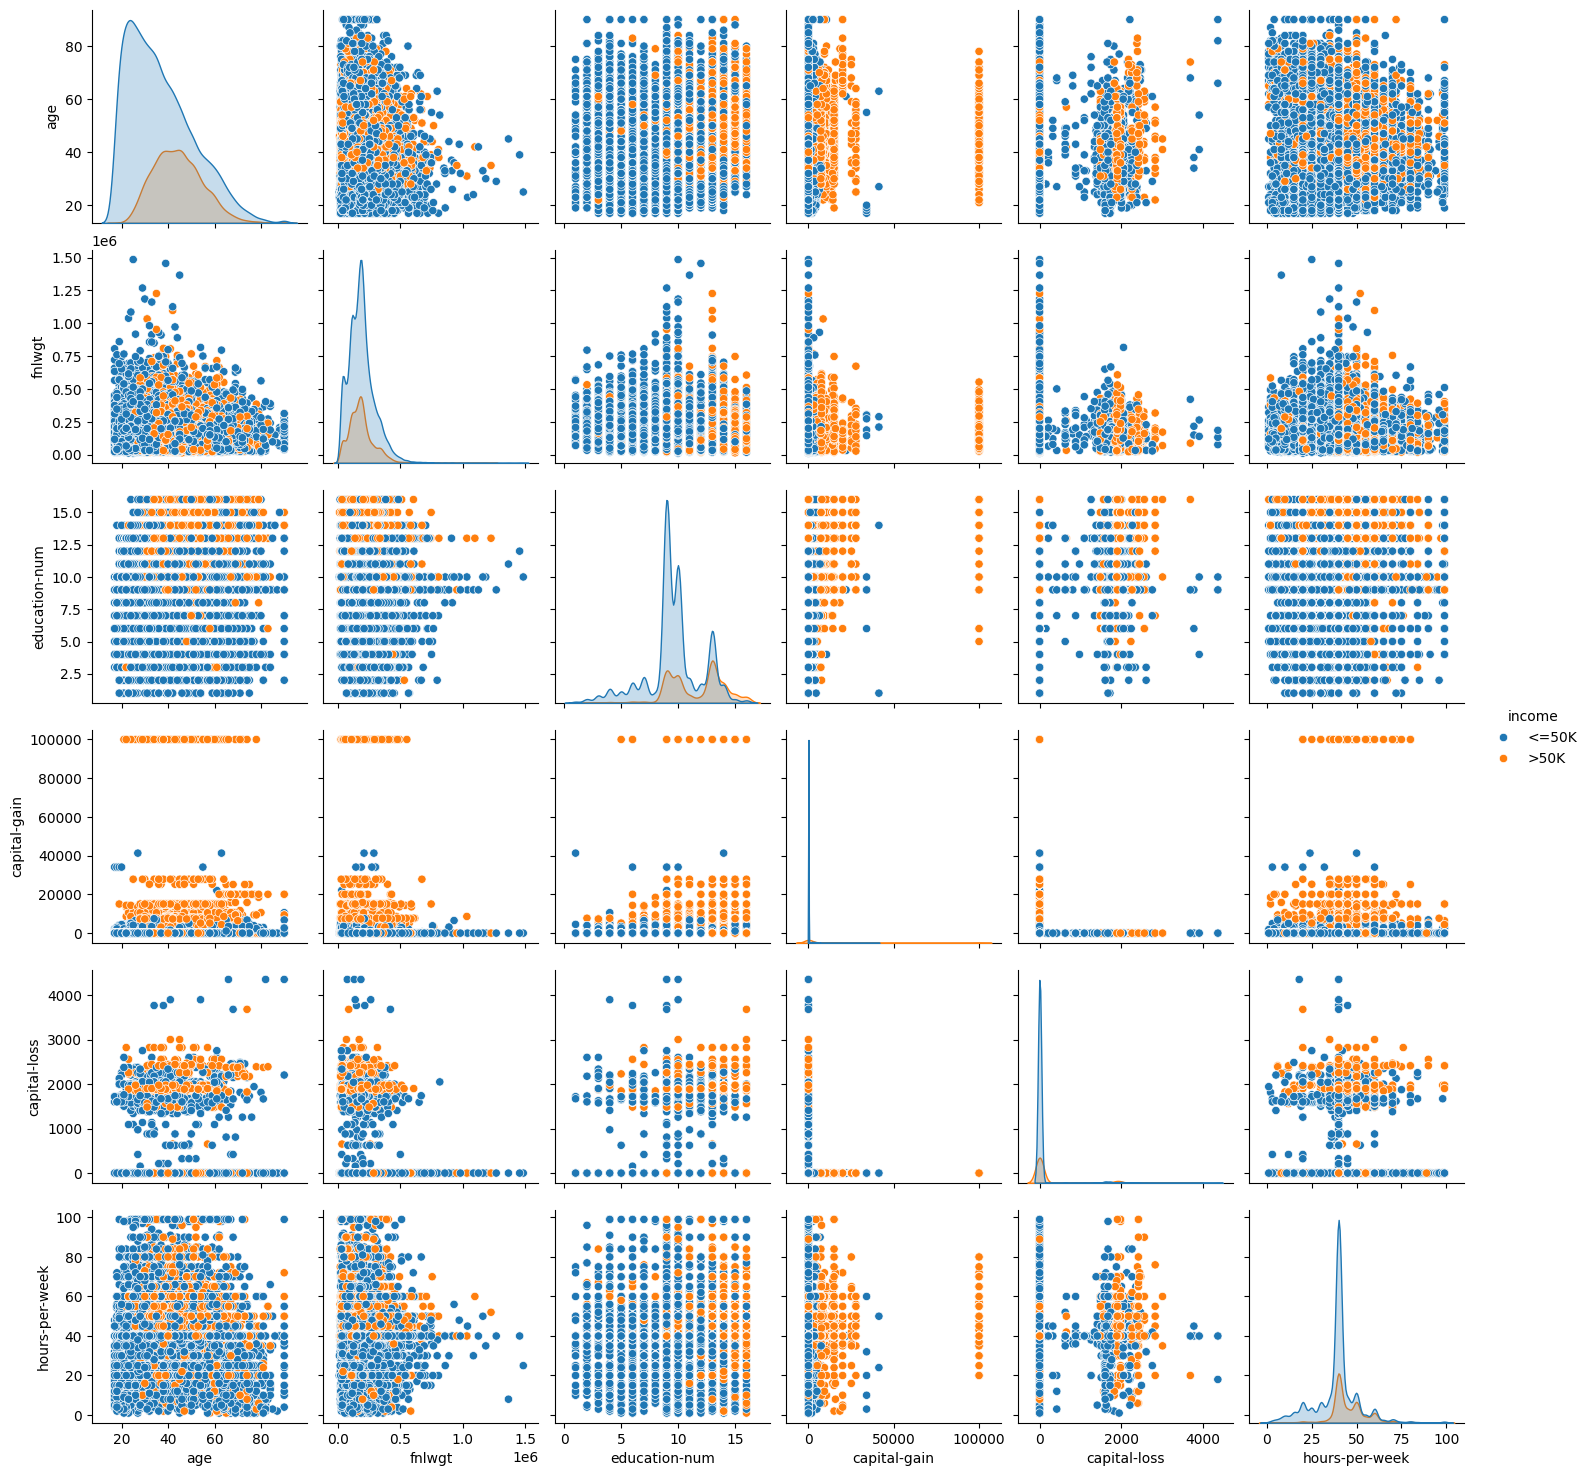

In [ ]:
sns.pairplot(df, vars=df[num_features], hue="income");

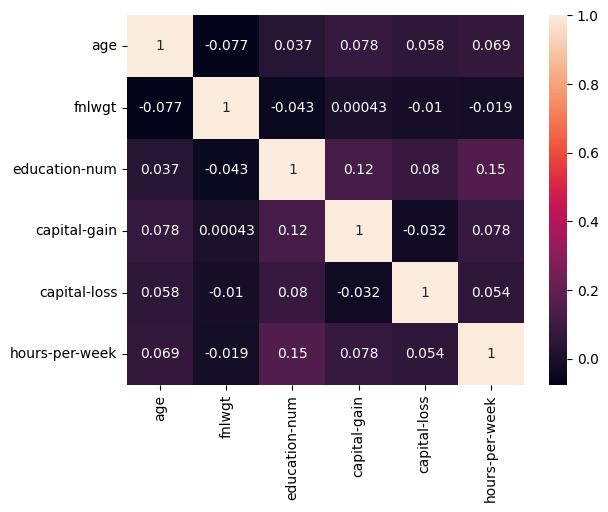

In [8]:
corr = df[num_features].corr()
sns.heatmap(corr, annot=True);

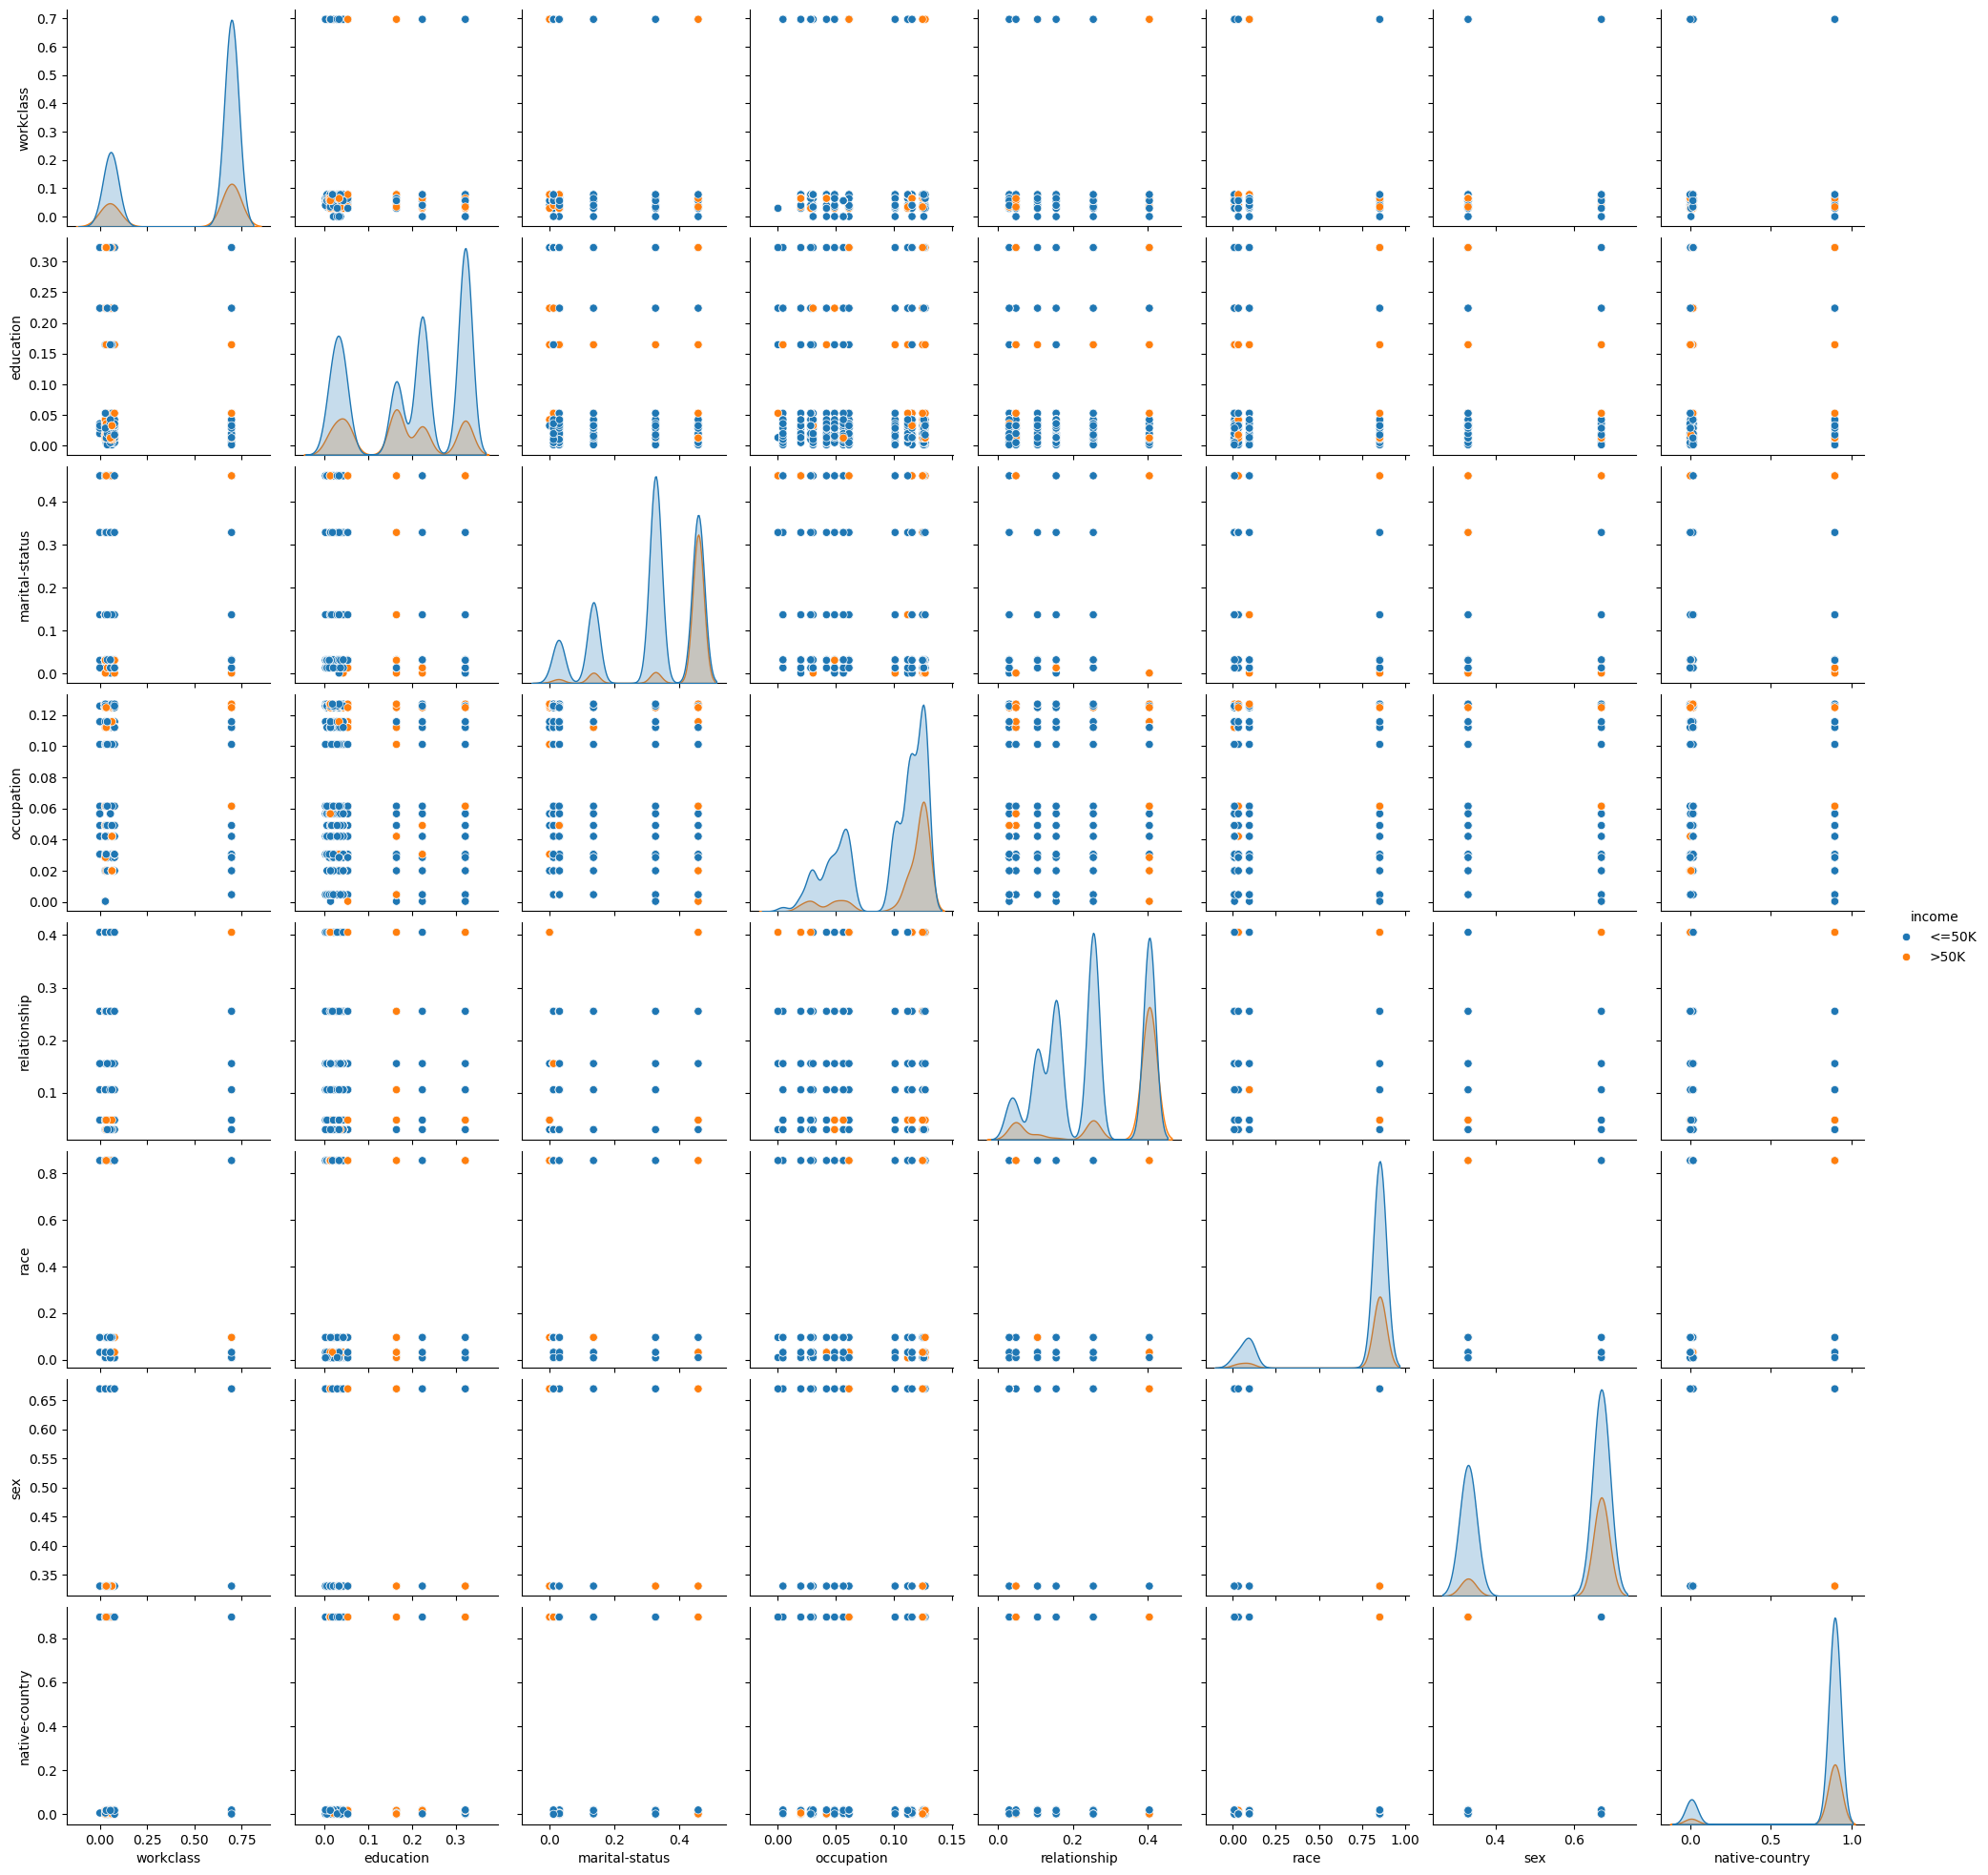

In [6]:
freq_cat_features = pd.DataFrame(df[cat_features].apply(lambda x : x.map(x.value_counts() / len(x))))
freq_cat_features["income"] = df["income"]
sns.pairplot(freq_cat_features, hue="income");

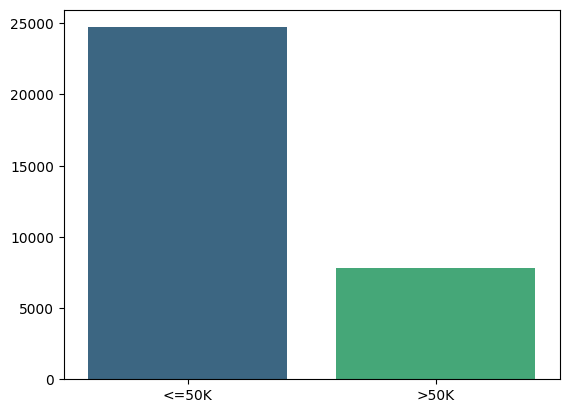

In [126]:
names , counts = np.unique(df["income"], return_counts=True)
# sns.histplot(counts)
sns.barplot(x=names, y=counts, palette="viridis", hue=names);

In [131]:
new_df = df.copy()
n_X = new_df.drop("income", axis=1)
n_y = new_df["income"]
n_X[cat_features] = freq_cat_features
mean = n_X.mean(axis=0)
std = n_X.std(axis=0)
n_X = (n_X - mean) / std

In [205]:
n_X

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.030670,-1.571500,-1.063594,-0.224998,1.134721,-0.084090,0.532806,-0.099944,0.412535,0.703061,0.148451,-0.216656,-0.035429,0.340934
1,0.837096,-1.441935,-1.008692,-0.224998,1.134721,0.855510,0.792630,1.070573,0.412535,0.703061,-0.145918,-0.216656,-2.222119,0.340934
2,-0.042641,0.658928,0.245075,1.144787,-0.420053,-1.449826,-1.573882,-0.099944,0.412535,0.703061,-0.145918,-0.216656,-0.035429,0.340934
3,1.057031,0.658928,0.425795,-1.337649,-1.197440,0.855510,-1.573882,1.070573,-2.329094,0.703061,-0.145918,-0.216656,-0.035429,0.340934
4,-0.775756,0.658928,1.408154,-0.224998,1.134721,0.855510,0.857587,-1.713237,-2.329094,-1.422309,-0.145918,-0.216656,-0.035429,-2.953460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,-0.849067,0.658928,0.639731,-1.366397,0.746028,0.855510,-1.961864,-1.713237,0.412535,-1.422309,-0.145918,-0.216656,-0.197406,0.340934
32557,0.103982,0.658928,-0.335428,1.144787,-0.420053,0.855510,-1.019121,1.070573,0.412535,0.703061,-0.145918,-0.216656,-0.035429,0.340934
32558,1.423588,0.658928,-0.358772,1.144787,-0.420053,-2.204920,0.532806,-1.263517,0.412535,-1.422309,-0.145918,-0.216656,-0.035429,0.340934
32559,-1.215625,0.658928,0.110958,1.144787,-0.420053,-0.084090,0.532806,-0.875101,0.412535,0.703061,-0.145918,-0.216656,-1.655199,0.340934


In [ ]:
X = new_df.drop("income", axis=1)
y = new_df["income"]

In [141]:
X

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,39,77516,13,2174,0,40
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,50,83311,13,0,0,13
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,38,215646,9,0,0,40
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,53,234721,7,0,0,40
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,28,338409,13,0,0,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,27,257302,12,0,0,38
32557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,40,154374,9,0,0,40
32558,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,58,151910,9,0,0,40
32559,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,22,201490,9,0,0,20


In [139]:
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y)

In [157]:
np.isclose(x_train.mean(axis=0), x_test.mean(axis=0), atol=1)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True, False, False,  True])

In [156]:
x_train

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
7257,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,40,55363,9,3411,0,40
9346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,27,177761,10,0,0,50
12375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,70,405362,4,0,0,38
6144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,57,562558,9,0,0,40
14117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,41,320984,15,99999,0,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4263,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,36,99270,9,0,0,40
3808,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,51,420917,13,0,0,45
10713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,26,187652,12,0,0,40
24602,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,52,74275,10,7298,0,45


In [158]:
df = pd.read_csv(url, header=None, names=columns, na_values=' ?', skipinitialspace=True)


In [165]:
df = df.replace("?" , np.nan)
df = df.dropna()
df[num_features].mean(axis=0)

age                   38.437902
fnlwgt            189793.833930
education-num         10.121312
capital-gain        1092.007858
capital-loss          88.372489
hours-per-week        40.931238
dtype: float64

In [169]:
df_num = df[num_features]
q1 = df_num.quantile(0.25)
q3 = df_num.quantile(0.75)
list(zip(q1 , q3))

[(28.0, 47.0),
 (117627.25, 237628.5),
 (9.0, 13.0),
 (0.0, 0.0),
 (0.0, 0.0),
 (40.0, 45.0)]

In [178]:
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR
outliers = (df_num < lower_bound) | (df_num > upper_bound)
cleaned_data = df_num[~outliers]
cleaned_data.isna().sum(), df_num.isna().sum()

(age                169
 fnlwgt             903
 education-num      196
 capital-gain      2538
 capital-loss      1427
 hours-per-week    7953
 dtype: int64,
 age               0
 fnlwgt            0
 education-num     0
 capital-gain      0
 capital-loss      0
 hours-per-week    0
 dtype: int64)

In [180]:
df_num_capped = df_num.copy()
df_num_capped = df_num_capped.clip(lower=lower_bound, upper=upper_bound, axis=1)
df_num_capped

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,39.0,77516.0,13,0,0,40.0
1,50.0,83311.0,13,0,0,32.5
2,38.0,215646.0,9,0,0,40.0
3,53.0,234721.0,7,0,0,40.0
4,28.0,338409.0,13,0,0,40.0
...,...,...,...,...,...,...
32556,27.0,257302.0,12,0,0,38.0
32557,40.0,154374.0,9,0,0,40.0
32558,58.0,151910.0,9,0,0,40.0
32559,22.0,201490.0,9,0,0,32.5


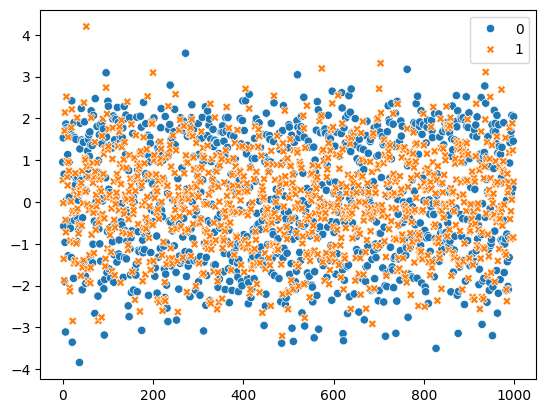

In [182]:
pca = sklearn.decomposition.PCA(2)
tsne = sklearn.manifold.TSNE(2)
pcs = pca.fit_transform(n_X[:1000])
sns.scatterplot(pcs);

In [184]:
pcs.shape

(1000, 2)

<Axes: >

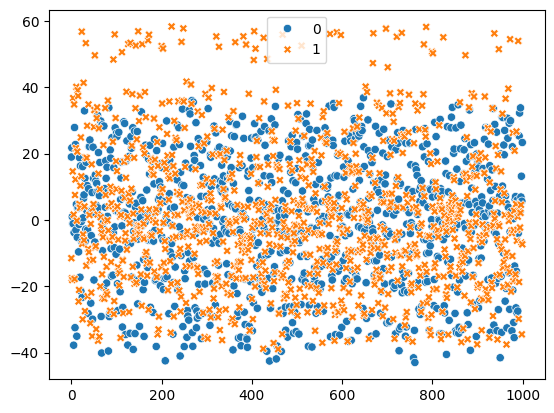

In [185]:
sns.scatterplot(tsne.fit_transform(n_X[:1000]))

In [ ]:
n_y = sklearn.preprocessing.LabelEncoder().fit_transform(n_y)

x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(n_X, n_y, stratify=n_y, shuffle=True)

In [250]:
sm = imblearn.over_sampling.SMOTENC(cat_features)
x_train, y_train = sm.fit_resample(x_train, y_train)


In [251]:
xgb_classifier.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [252]:
print(sklearn.metrics.classification_report(y_test, (xgb_classifier.predict(x_test))))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      6180
           1       0.90      0.90      0.90      6180

    accuracy                           0.90     12360
   macro avg       0.90      0.90      0.90     12360
weighted avg       0.90      0.90      0.90     12360



In [246]:
rf_balance = imblearn.ensemble.BalancedBaggingClassifier()
rf_balance.fit(x_train, y_train)

,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,sampling_strategy,'auto'
,replacement,False
,n_jobs,None


In [247]:
print(sklearn.metrics.classification_report(y_test, rf_balance.predict(x_test)))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88      6180
           1       0.89      0.86      0.88      6180

    accuracy                           0.88     12360
   macro avg       0.88      0.88      0.88     12360
weighted avg       0.88      0.88      0.88     12360



In [254]:
xgb_classifier.fit(np.zeros_like(x_train), y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [255]:
print(sklearn.metrics.classification_report(y_test, (xgb_classifier.predict(x_test))))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67      6180
           1       0.00      0.00      0.00      6180

    accuracy                           0.50     12360
   macro avg       0.25      0.50      0.33     12360
weighted avg       0.25      0.50      0.33     12360



c:\Users\alien\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alien\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alien\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [276]:
xgb_classifier = xgboost.XGBClassifier(max_depth=100, n_estimators=10000, min_child_weight=1, reg_alpha=0, reg_lambda=0)
# model = sklearn.ensemble.BaggingClassifier(estimator=sklearn.tree.DecisionTreeClassifier())
xgb_classifier.fit(x_train[100:150], y_train[100:150], )
print(sklearn.metrics.classification_report(y_train[100:150], (xgb_classifier.predict(x_train[100:150]))))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        27

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [268]:
y_train[:5]

array([0, 0, 1, 1, 0])

In [274]:
import xgboost as xgb
from sklearn.metrics import classification_report

xgb_classifier = xgb.XGBClassifier(
    max_depth=100,        # deep trees
    n_estimators=10000,   # lots of trees
    learning_rate=1,      # aggressive step size
    min_child_weight=1,   # split even tiny nodes
    subsample=1.0,        # use all rows
    colsample_bytree=1.0, # use all features
    gamma=0,              # no min loss reduction
    reg_alpha=0,          # no L1
    reg_lambda=0,         # no L2
    use_label_encoder=False,
    verbosity=0
)

# tiny training slice
x_train_slice = x_train[100:105]
y_train_slice = y_train[100:105]

xgb_classifier.fit(x_train_slice, y_train_slice)

y_pred = xgb_classifier.predict(x_train_slice)
print(classification_report(y_train_slice, y_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.60      1.00      0.75         3

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5



In [281]:
print(classification_report(y_train, np.where(x_train.mean(axis=1) > 0 , 1, 0))) 

              precision    recall  f1-score   support

           0       0.78      0.61      0.68     18540
           1       0.68      0.83      0.74     18540

    accuracy                           0.72     37080
   macro avg       0.73      0.72      0.71     37080
weighted avg       0.73      0.72      0.71     37080

